In [1]:
import pandas as pd
import ipeadatapy as ip
import datetime
import time
import sidrapy
from bcb import sgs
import matplotlib.pyplot as plt

c:\Users\50122030\poc-demand-forecast\pocenv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


In [2]:
df = pd.read_excel('./Dados Silver/Performance.xlsx', engine='openpyxl')

In [3]:
df.head()

,Categoria,Especificação,Data,Valor
0,Consumo Aparente / Apparent Consumption (***),Consumo Aparente / Apparent Consumption (***),2013-01-01,2167.705
1,Consumo Aparente / Apparent Consumption (***),Consumo Aparente / Apparent Consumption (***),2013-02-01,2069.840
2,Consumo Aparente / Apparent Consumption (***),Consumo Aparente / Apparent Consumption (***),2013-03-01,2330.914
3,Consumo Aparente / Apparent Consumption (***),Consumo Aparente / Apparent Consumption (***),2013-04-01,2402.633
4,Consumo Aparente / Apparent Consumption (***),Consumo Aparente / Apparent Consumption (***),2013-05-01,2456.820


In [4]:
df.shape

(6123, 4)

# Filtrar somente a categoria "Produção / Production" e a especificação "Longos / Long Products"

In [5]:
df_producao_longos = df[(df['Categoria'] == 'Produção / Production') & (df['Especificação'] == 'Longos / Long Products')].copy()

In [6]:
df_producao_longos.head()

,Categoria,Especificação,Data,Valor
3297,Produção / Production,Longos / Long Products,2013-01-01,848.959
3298,Produção / Production,Longos / Long Products,2013-02-01,798.758
3299,Produção / Production,Longos / Long Products,2013-03-01,932.738
3300,Produção / Production,Longos / Long Products,2013-04-01,978.522
3301,Produção / Production,Longos / Long Products,2013-05-01,1043.302


# Séries do IPEA

In [7]:
for index, row in ip.list_series().iterrows():
    if 'FBC' in row['NAME']:
        print(f"{row['CODE']} - {row['NAME']}")

GAC12_INDFBCF12 - Indicador IPEA de FBCF - índice real (média 1995 = 100)
GAC12_INDFBCFCC12 - Indicador IPEA de FBCF - construção civil - índice real (média1995 = 100)
GAC12_INDFBCFCCDESSAZ12 - Indicador IPEA de FBCF - construção civil - índice real dessazonalizado (média 1995 = 100)
GAC12_INDFBCFDESSAZ12 - Indicador IPEA de FBCF - índice real dessazonalizado (média 1995 = 100)
SCN10_FBKF10 - PIB - FBCF - índice real (base 2010 = 100)
SCN10_FBKFCG10 - PIB - FBCF - construçao - var real anual
SCN10_FBKFCN10 - PIB - FBCF - construçao
SCN10_FBKFG10 - PIB - FBCF - var real anual
SCN10_FBKFM10 - PIB - FBCF - maq_equip -  índice real (base 2010 = 100)
SCN10_FBKFMN10 - PIB - FBCF - maq_equip
SCN10_FBKFMP10 - PIB - FBCF - maq_equip  (preços 2010)
SCN10_FBKFN10 - PIB - FBCF
SCN10_FBKFOG10 - PIB - FBCF - outros -  var real anual
SCN10_FBKFON10 - PIB - FBCF - outros
SCN10_FBKFP10 - PIB - FBCF (preços 2010)


## SELIC

In [8]:
df_selic = ip.timeseries('PAN12_TJOVER12')
df_selic.reset_index(inplace=True)
df_selic.rename(columns={'DATE': 'Date'}, inplace=True)

In [9]:
df_selic = df_selic[df_selic['Date'] > pd.Timestamp(2012, 12, 31)].copy()
df_selic.reset_index(drop=True, inplace=True)

In [10]:
df_selic.drop(['CODE', 'RAW DATE', 'DAY', 'MONTH', 'YEAR'], axis=1, inplace=True)
df_selic.fillna(0, inplace=True)

,Date,VALUE ((% a.a.))
0,2013-01-01,7.442417
1,2013-02-01,6.041083
2,2013-03-01,6.803356
3,2013-04-01,7.570649
4,2013-05-01,7.442417
...,...,...
154,2025-11-01,13.353730
155,2025-12-01,15.663411
156,2026-01-01,14.843349
157,2026-02-01,12.682503


In [11]:
df_selic.rename(columns={'VALUE ((% a.a.))':'taxa_selic_aa'}, inplace=True)

In [13]:
df_selic

,Date,taxa_selic_aa
0,2013-01-01,7.442417
1,2013-02-01,6.041083
2,2013-03-01,6.803356
3,2013-04-01,7.570649
4,2013-05-01,7.442417
...,...,...
154,2025-11-01,13.353730
155,2025-12-01,15.663411
156,2026-01-01,14.843349
157,2026-02-01,12.682503


In [14]:
df_selic.to_excel('./Dados Silver/ipea_selic.xlsx', index=False, engine='openpyxl')

## FBC - Formação Bruta de Capital

In [15]:
df_fbc = ip.timeseries('GAC12_INDFBCFDESSAZ12')
df_fbc.reset_index(inplace=True)
df_fbc.rename(columns={'DATE': 'Date'}, inplace=True)

In [16]:
df_fbc = df_fbc[df_fbc['Date'] > pd.Timestamp(2012, 12, 31)].copy()
df_fbc.reset_index(drop=True, inplace=True)

In [17]:
df_fbc.drop(['CODE', 'RAW DATE', 'DAY', 'MONTH', 'YEAR'], axis=1, inplace=True)
df_fbc.fillna(0, inplace=True)

,Date,VALUE (-)
0,2013-01-01,186.430606
1,2013-02-01,189.935751
2,2013-03-01,189.989204
3,2013-04-01,204.242975
4,2013-05-01,195.255797
...,...,...
150,2025-07-01,180.498771
151,2025-08-01,176.758191
152,2025-09-01,191.814434
153,2025-10-01,177.496031


In [18]:
df_fbc.rename(columns={'VALUE (-)':'formacao_bruta_capital'}, inplace=True)

In [19]:
df_fbc

,Date,formacao_bruta_capital
0,2013-01-01,186.430606
1,2013-02-01,189.935751
2,2013-03-01,189.989204
3,2013-04-01,204.242975
4,2013-05-01,195.255797
...,...,...
150,2025-07-01,180.498771
151,2025-08-01,176.758191
152,2025-09-01,191.814434
153,2025-10-01,177.496031


In [20]:
df_fbc.to_excel('./Dados Silver/ipea_fbc.xlsx', index=False, engine='openpyxl')

## PIB

In [111]:
#ip.timeseries('BM12_PIB12')

## Taxa de câmbio

In [21]:
df_cambio = ip.timeseries('GM366_ERC366')
df_cambio.reset_index(inplace=True)
df_cambio.rename(columns={'DATE': 'Date'}, inplace=True)

In [22]:
df_cambio = df_cambio[df_cambio['Date'] > pd.Timestamp(2012, 12, 31)].copy()
df_cambio.reset_index(drop=True, inplace=True)

In [23]:
df_cambio.drop(['CODE', 'RAW DATE', 'DAY', 'MONTH', 'YEAR'], axis=1, inplace=True)
df_cambio.fillna(0, inplace=True)

,Date,VALUE (R$ ou u.m.c.)
0,2013-01-01,0.0000
1,2013-01-02,2.0409
2,2013-01-03,2.0458
3,2013-01-04,2.0419
4,2013-01-05,0.0000
...,...,...
3659,2026-03-10,5.1616
3660,2026-03-11,5.1590
3661,2026-03-12,5.2045
3662,2026-03-13,5.2535


In [24]:
df_cambio = df_cambio.groupby(pd.Grouper(key='Date', freq='MS')).mean().reset_index().copy()

In [25]:
df_cambio.rename(columns={'VALUE (R$ ou u.m.c.)':'valor_cambio_reais'}, inplace=True)

In [26]:
df_cambio

,Date,valor_cambio_reais
0,2013-01-01,1.440984
1,2013-02-01,1.268150
2,2013-03-01,1.278884
3,2013-04-01,1.467863
4,2013-05-01,1.378052
...,...,...
154,2025-11-01,5.340253
155,2025-12-01,5.452482
156,2026-01-01,5.337419
157,2026-02-01,5.200011


In [27]:
df_cambio.to_excel('./Dados Silver/ipea_cambio.xlsx', index=False, engine='openpyxl')

# Séries Banco Central - Crédito

https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries

https://wilsonfreitas.github.io/python-bcb/index.html

1. 22030 - Saldo das operações de crédito por atividade econômica - Indústria de construção
2. 27725 - Saldo das operações de crédito por atividade econômica - Indústria de obras de infraestrutura
3. 27748 - Saldo das operações de crédito por atividade econômica - Indústria de metalurgia e siderurgia

## SELIC

In [30]:
df_selic_1 = sgs.get(codes=('SELIC', 432), start=datetime.datetime(2012, 12, 31), end=datetime.datetime(2019, 12, 31))
#df_selic_1 = sgs.get(codes=('SELIC', 432), start=datetime.datetime(2016, 1, 1), end=datetime.datetime(2019, 12, 31))
df_selic_1.reset_index(inplace=True)

In [31]:
df_selic_2 = sgs.get(codes=('SELIC', 432), start=datetime.datetime(2020, 1, 1))
df_selic_2.reset_index(inplace=True)

In [32]:
df_selic_1_grouped = df_selic_1.groupby([pd.Grouper(key='Date', freq='MS')]).mean().reset_index().copy()
df_selic_2_grouped = df_selic_2.groupby([pd.Grouper(key='Date', freq='MS')]).mean().reset_index().copy()

In [33]:
df_selic = pd.concat([df_selic_1_grouped, df_selic_2_grouped]).copy()

In [36]:
df_selic

,Date,SELIC
0,2012-12-01,7.250000
1,2013-01-01,7.250000
2,2013-02-01,7.250000
3,2013-03-01,7.250000
4,2013-04-01,7.358333
...,...,...
70,2025-11-01,15.000000
71,2025-12-01,15.000000
72,2026-01-01,15.000000
73,2026-02-01,15.000000


In [35]:
df_selic.to_excel('./Dados Silver/bc_sgs_projecao_selic.xlsx', index=False, engine='openpyxl')

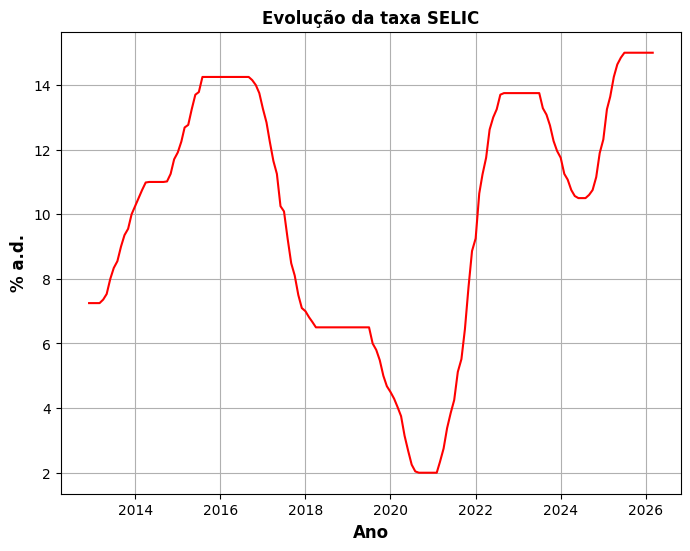

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(df_selic['Date'], df_selic['SELIC'], 'r')
plt.ylabel('% a.d.', fontsize=12, fontweight='bold')
plt.xlabel('Ano', fontsize=12, fontweight='bold')
plt.title('Evolução da taxa SELIC', fontsize=12, fontweight='bold')
plt.grid()

## IPCA e PIB

In [38]:
df_economia = sgs.get(codes=[('IPCA', 433),
    ('PIB_mensal', 4380)])
df_economia.reset_index(inplace=True)

In [39]:
df_economia = df_economia[df_economia['Date'] > pd.Timestamp(2012, 12, 31)].copy()
df_economia.reset_index(drop=True, inplace=True)

In [40]:
df_economia

,Date,IPCA,PIB_mensal
0,2013-01-01,0.86,408895.0
1,2013-02-01,0.60,398087.4
2,2013-03-01,0.47,434631.2
3,2013-04-01,0.55,446508.1
4,2013-05-01,0.37,441322.0
...,...,...,...
153,2025-10-01,0.09,1107951.1
154,2025-11-01,0.18,1084709.5
155,2025-12-01,0.33,1085129.6
156,2026-01-01,0.33,1023703.2


In [41]:
df_economia.to_excel('./Dados Silver/bc_sgs_ipca_pib.xlsx', index=False, engine='openpyxl')

## Crédito na indústria

In [42]:
df_operacoes_credito_industria = sgs.get(codes=[('operacoes_credito_industria_construcao', 22030), 
    ('operacoes_credito_industria_infraestrutura', 27725), 
    ('operacoes_credito_industria_metalurgia_siderurgia', 27748)])
df_operacoes_credito_industria.reset_index(inplace=True)

In [45]:
df_operacoes_credito_industria

,Date,operacoes_credito_industria_construcao,operacoes_credito_industria_infraestrutura,operacoes_credito_industria_metalurgia_siderurgia
0,2012-01-01,77754,21887,47118
1,2012-02-01,78890,22346,47431
2,2012-03-01,80919,22620,47472
3,2012-04-01,82271,23106,47523
4,2012-05-01,84393,23735,47347
...,...,...,...,...
164,2025-09-01,156706,35396,54928
165,2025-10-01,158600,36032,54526
166,2025-11-01,160270,35705,54036
167,2025-12-01,163044,36253,57662


In [44]:
df_operacoes_credito_industria.shape

(169, 4)

In [46]:
df_operacoes_credito_industria.to_excel("./Dados Silver/bc_sgs_operacoes_credito_industria.xlsx", index=False, engine="openpyxl")

# Séries do SIDRA/IBGE

1. '1': Brasil (Nacional)
2. '2': Grandes Regiões (Norte, Nordeste, Sul, etc.)
3. '3': Unidades da Federação / Estados
4. '6': Municípios
5. '7': Regiões Metropolitanas

In [137]:
#df = sidrapy.get_table(table_code='647', territorial_level='1', ibge_territorial_code='all', period='last 24')
#df = sidrapy.get_table(table_code='647', territorial_level='3', ibge_territorial_code='all', period='last 120')

In [138]:
#df.head()

## Custo projeto $m^2$

In [47]:
# Códigos das 27 UFs do Brasil (para não estourarmos o limite de 50k pedindo tudo de uma vez)
ufs = [
    '11', '12', '13', '14', '15', '16', '17', '21', '22', '23', 
    '24', '25', '26', '27', '28', '29', '31', '32', '33', '35', 
    '41', '42', '43', '50', '51', '52', '53'
]

dataframes = []

for uf in ufs:
    print(f"Baixando dados do estado {uf}...")
    # classifications={'314': 'all', '41': 'all'} traz todas as variáveis de Projeto e Acabamento
    df_uf = sidrapy.get_table(
        table_code='647', 
        territorial_level='3',           # UF
        ibge_territorial_code=uf,        # Consultando 1 estado por vez
        period='last 144',               # Últimos 10 anos
        classifications={'314': 'all', '41': 'all'} # Tipo e Padrão - Essencial para não vir vazio!
    )
    dataframes.append(df_uf)
    time.sleep(0.5) # Pausa pequena para não ser bloqueado por tax rate excessivo no IBGE

# Junta todos os estados
df_completo = pd.concat(dataframes, ignore_index=True)

# Remove a primeira linha se ela contiver os nomes das colunas (retorno padrão da API)
if df_completo.iloc[0]['D1C'] == 'Nível Territorial (Código)':
    df_completo.columns = df_completo.iloc[0]
    df_completo = df_completo[1:]

Baixando dados do estado 11...
Baixando dados do estado 12...
Baixando dados do estado 13...
Baixando dados do estado 14...
Baixando dados do estado 15...
Baixando dados do estado 16...
Baixando dados do estado 17...
Baixando dados do estado 21...
Baixando dados do estado 22...
Baixando dados do estado 23...
Baixando dados do estado 24...
Baixando dados do estado 25...
Baixando dados do estado 26...
Baixando dados do estado 27...
Baixando dados do estado 28...
Baixando dados do estado 29...
Baixando dados do estado 31...
Baixando dados do estado 32...
Baixando dados do estado 33...
Baixando dados do estado 35...
Baixando dados do estado 41...
Baixando dados do estado 42...
Baixando dados do estado 43...
Baixando dados do estado 50...
Baixando dados do estado 51...
Baixando dados do estado 52...
Baixando dados do estado 53...


In [49]:
index = 0
for i in range(len(df_completo.columns)):
    df_completo.rename(columns={df_completo.columns[index]: df_completo.iloc[0].values[index]}, inplace=True)
    index += 1
df_completo.drop(0, axis=0, inplace=True)
df_completo.reset_index(drop=True, inplace=True)

In [141]:
#df_completo = pd.read_excel('./Dados/sidra_sinapi_m2.xlsx', engine='openpyxl')

In [51]:
df_completo.head()

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Mês (Código),Mês,Tipo de projeto (Código),Tipo de projeto,Padrão de acabamento (Código),Padrão de acabamento,Variável (Código),Variável
0,3,Unidade da Federação,38,Reais,-,11,Rondônia,201403,março 2014,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",786,Alto,51,Custo de projeto m²
1,3,Unidade da Federação,38,Reais,961.01,11,Rondônia,201403,março 2014,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",787,Normal,51,Custo de projeto m²
2,3,Unidade da Federação,38,Reais,691.55,11,Rondônia,201403,março 2014,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",788,Baixo,51,Custo de projeto m²
3,3,Unidade da Federação,38,Reais,597.19,11,Rondônia,201403,março 2014,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",789,Mínimo,51,Custo de projeto m²
4,3,Unidade da Federação,38,Reais,-,11,Rondônia,201403,março 2014,7088,"CP.1-2Q.....40 Casa popular, 1 pavimento, sala...",786,Alto,51,Custo de projeto m²


In [52]:
df_completo.to_excel('./Dados/sidra_sinapi_m2.xlsx', index=False, engine='openpyxl')

In [53]:
def ajustar_valores(valor):
    if valor == '-':
        return 0
    else:
        return float(valor)

In [54]:
df_completo = df_completo[df_completo['Mês (Código)'] != 'Mês (Código)'].copy()
df_completo.reset_index(drop=True, inplace=True)
df_completo['Date'] = df_completo['Mês (Código)'].apply(lambda x : datetime.datetime.strptime(x, '%Y%m'))
df_completo.drop(['Mês (Código)', 'Mês', 'Nível Territorial (Código)', 'Nível Territorial', 'Unidade de Medida (Código)', 'Unidade de Medida'], axis=1, inplace=True)
df_completo['Valor'] = df_completo['Valor'].apply(ajustar_valores)

In [55]:
df_completo.head()

,Valor,Unidade da Federação (Código),Unidade da Federação,Tipo de projeto (Código),Tipo de projeto,Padrão de acabamento (Código),Padrão de acabamento,Variável (Código),Variável,Date
0,0.00,11,Rondônia,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",786,Alto,51,Custo de projeto m²,2014-03-01
1,961.01,11,Rondônia,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",787,Normal,51,Custo de projeto m²,2014-03-01
2,691.55,11,Rondônia,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",788,Baixo,51,Custo de projeto m²,2014-03-01
3,597.19,11,Rondônia,7087,"CP.1-2Q.....46 Casa popular, 1 pavimento, vara...",789,Mínimo,51,Custo de projeto m²,2014-03-01
4,0.00,11,Rondônia,7088,"CP.1-2Q.....40 Casa popular, 1 pavimento, sala...",786,Alto,51,Custo de projeto m²,2014-03-01


In [56]:
df_custo_projeto_m2 = df_completo[df_completo['Valor'] != '-'].groupby([pd.Grouper(key='Date', freq='MS')])['Valor'].sum().reset_index()

In [57]:
df_custo_projeto_m2.rename(columns={'Valor':'custo_projeto_m2'}, inplace=True)

In [59]:
df_custo_projeto_m2

,Date,custo_projeto_m2
0,2014-03-01,1789677.76
1,2014-04-01,1795689.30
2,2014-05-01,1809898.74
3,2014-06-01,1822703.31
4,2014-07-01,1835144.66
...,...,...
139,2025-10-01,3906633.17
140,2025-11-01,3917134.22
141,2025-12-01,3929314.11
142,2026-01-01,3944742.89


In [60]:
df_custo_projeto_m2.to_excel('./Dados Silver/sidra_sinapi_m2.xlsx', index=False, engine='openpyxl')

## Pesquisa industrial mensal PIM-PF

In [61]:
# Códigos das 27 UFs
ufs = [
    '11', '12', '13', '14', '15', '16', '17', '21', '22', '23', 
    '24', '25', '26', '27', '28', '29', '31', '32', '33', '35', 
    '41', '42', '43', '50', '51', '52', '53'
]

dataframes_8888 = []

for uf in ufs:
    print(f"Baixando dados industriais do estado {uf}...")
    
    # classifications={'544': 'all'} traz todos os setores industriais da CNAE 2.0
    # variables='all' assegura que todas as 6 variações (número índice, variação m/m-1, etc) venham.
    df_uf = sidrapy.get_table(
        table_code='8888', 
        territorial_level='3',       
        ibge_territorial_code=uf,    
        period='last 144',           
        variables='all',
        classifications={'544': 'all'} 
    )
    
    dataframes_8888.append(df_uf)
    time.sleep(0.5) # Proteção contra bloqueio do IBGE

# Junta os estados
df_pim_pf = pd.concat(dataframes_8888, ignore_index=True)

# Limpa a primeira linha do cabeçalho da API se houver
if df_pim_pf.iloc[0]['D1C'] == 'Nível Territorial (Código)':
    df_pim_pf.columns = df_pim_pf.iloc[0]
    df_pim_pf = df_pim_pf[1:]

print("Dados Extraídos com Sucesso! Tamanho total:", df_pim_pf.shape)

Baixando dados industriais do estado 11...
Baixando dados industriais do estado 12...
Baixando dados industriais do estado 13...
Baixando dados industriais do estado 14...
Baixando dados industriais do estado 15...
Baixando dados industriais do estado 16...
Baixando dados industriais do estado 17...
Baixando dados industriais do estado 21...
Baixando dados industriais do estado 22...
Baixando dados industriais do estado 23...
Baixando dados industriais do estado 24...
Baixando dados industriais do estado 25...
Baixando dados industriais do estado 26...
Baixando dados industriais do estado 27...
Baixando dados industriais do estado 28...
Baixando dados industriais do estado 29...
Baixando dados industriais do estado 31...
Baixando dados industriais do estado 32...
Baixando dados industriais do estado 33...
Baixando dados industriais do estado 35...
Baixando dados industriais do estado 41...
Baixando dados industriais do estado 42...
Baixando dados industriais do estado 43...
Baixando da

In [62]:
index = 0
for i in range(len(df_pim_pf.columns)):
    df_pim_pf.rename(columns={df_pim_pf.columns[index]: df_pim_pf.iloc[0].values[index]}, inplace=True)
    index += 1
df_pim_pf.drop(0, axis=0, inplace=True)
df_pim_pf.reset_index(drop=True, inplace=True)

In [63]:
df_pim_pf

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Mês (Código),Mês,Seções e atividades industriais (CNAE 2.0) (Código),Seções e atividades industriais (CNAE 2.0),Variável (Código),Variável
0,3,Unidade da Federação,30,Número-índice,...,11,Rondônia,201402,fevereiro 2014,129314,1 Indústria geral,12606,PIMPF - Número-índice (2022=100)
1,3,Unidade da Federação,30,Número-índice,...,11,Rondônia,201402,fevereiro 2014,129314,1 Indústria geral,12607,PIMPF - Número-índice com ajuste sazonal (2022...
2,3,Unidade da Federação,2,%,...,11,Rondônia,201402,fevereiro 2014,129314,1 Indústria geral,11601,PIMPF - Variação mês/mês imediatamente anterio...
3,3,Unidade da Federação,2,%,...,11,Rondônia,201402,fevereiro 2014,129314,1 Indústria geral,11602,PIMPF - Variação mês/mesmo mês do ano anterior...
4,3,Unidade da Federação,2,%,...,11,Rondônia,201402,fevereiro 2014,129314,1 Indústria geral,11603,PIMPF - Variação acumulada no ano (em relação ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629877,3,Unidade da Federação,30,Número-índice,...,53,Distrito Federal,202601,janeiro 2026,129342,"3.33 Manutenção, reparação e instalação de máq...",12607,PIMPF - Número-índice com ajuste sazonal (2022...
629878,3,Unidade da Federação,2,%,...,53,Distrito Federal,202601,janeiro 2026,129342,"3.33 Manutenção, reparação e instalação de máq...",11601,PIMPF - Variação mês/mês imediatamente anterio...
629879,3,Unidade da Federação,2,%,...,53,Distrito Federal,202601,janeiro 2026,129342,"3.33 Manutenção, reparação e instalação de máq...",11602,PIMPF - Variação mês/mesmo mês do ano anterior...
629880,3,Unidade da Federação,2,%,...,53,Distrito Federal,202601,janeiro 2026,129342,"3.33 Manutenção, reparação e instalação de máq...",11603,PIMPF - Variação acumulada no ano (em relação ...


In [64]:
df_pim_pf.to_excel('./Dados/sidra_pim_pf.xlsx', engine='openpyxl')

In [65]:
def ajustar_valores(valor):
    if valor == '...' or valor == '-':
        return 0
    else:
        return float(valor)

In [66]:
df_pim_pf = df_pim_pf[df_pim_pf['Mês (Código)'] != 'Mês (Código)'].copy()
df_pim_pf.reset_index(drop=True, inplace=True)
df_pim_pf['Date'] = df_pim_pf['Mês (Código)'].apply(lambda x : datetime.datetime.strptime(x, '%Y%m'))
df_pim_pf.drop(['Mês (Código)', 'Mês', 'Nível Territorial (Código)', 'Nível Territorial', 'Unidade de Medida (Código)', 'Unidade de Medida'], axis=1, inplace=True)
df_pim_pf['Valor'] = df_pim_pf['Valor'].apply(ajustar_valores)

In [67]:
df_pim_pf

,Valor,Unidade da Federação (Código),Unidade da Federação,Seções e atividades industriais (CNAE 2.0) (Código),Seções e atividades industriais (CNAE 2.0),Variável (Código),Variável,Date
0,0.0,11,Rondônia,129314,1 Indústria geral,12606,PIMPF - Número-índice (2022=100),2014-02-01
1,0.0,11,Rondônia,129314,1 Indústria geral,12607,PIMPF - Número-índice com ajuste sazonal (2022...,2014-02-01
2,0.0,11,Rondônia,129314,1 Indústria geral,11601,PIMPF - Variação mês/mês imediatamente anterio...,2014-02-01
3,0.0,11,Rondônia,129314,1 Indústria geral,11602,PIMPF - Variação mês/mesmo mês do ano anterior...,2014-02-01
4,0.0,11,Rondônia,129314,1 Indústria geral,11603,PIMPF - Variação acumulada no ano (em relação ...,2014-02-01
...,...,...,...,...,...,...,...,...
629851,0.0,53,Distrito Federal,129342,"3.33 Manutenção, reparação e instalação de máq...",12607,PIMPF - Número-índice com ajuste sazonal (2022...,2026-01-01
629852,0.0,53,Distrito Federal,129342,"3.33 Manutenção, reparação e instalação de máq...",11601,PIMPF - Variação mês/mês imediatamente anterio...,2026-01-01
629853,0.0,53,Distrito Federal,129342,"3.33 Manutenção, reparação e instalação de máq...",11602,PIMPF - Variação mês/mesmo mês do ano anterior...,2026-01-01
629854,0.0,53,Distrito Federal,129342,"3.33 Manutenção, reparação e instalação de máq...",11603,PIMPF - Variação acumulada no ano (em relação ...,2026-01-01


In [68]:
#filtrar_variavel = ['PIMPF - Número-índice com ajuste sazonal (2022=100)']
filtrar_variavel = ['PIMPF - Número-índice (2022=100)']
filtrar_secoes = ['3.24 Metalurgia', '3.28 Fabricação de máquinas e equipamentos', '3.29 Fabricação de veículos automotores, reboques e carrocerias',
    '3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores']

In [69]:
df_pim_pf_filtrado = df_pim_pf[(df_pim_pf['Variável'].isin(filtrar_variavel)) & (df_pim_pf['Seções e atividades industriais (CNAE 2.0)'].isin(filtrar_secoes))].copy()
df_pim_pf_filtrado.reset_index(drop=True, inplace=True)

In [70]:
df_pim_pf_filtrado

,Valor,Unidade da Federação (Código),Unidade da Federação,Seções e atividades industriais (CNAE 2.0) (Código),Seções e atividades industriais (CNAE 2.0),Variável (Código),Variável,Date
0,0.0,11,Rondônia,129333,3.24 Metalurgia,12606,PIMPF - Número-índice (2022=100),2014-02-01
1,0.0,11,Rondônia,129337,3.28 Fabricação de máquinas e equipamentos,12606,PIMPF - Número-índice (2022=100),2014-02-01
2,0.0,11,Rondônia,129338,"3.29 Fabricação de veículos automotores, reboq...",12606,PIMPF - Número-índice (2022=100),2014-02-01
3,0.0,11,Rondônia,129339,3.30 Fabricação de outros equipamentos de tran...,12606,PIMPF - Número-índice (2022=100),2014-02-01
4,0.0,11,Rondônia,129333,3.24 Metalurgia,12606,PIMPF - Número-índice (2022=100),2014-03-01
...,...,...,...,...,...,...,...,...
15547,0.0,53,Distrito Federal,129339,3.30 Fabricação de outros equipamentos de tran...,12606,PIMPF - Número-índice (2022=100),2025-12-01
15548,0.0,53,Distrito Federal,129333,3.24 Metalurgia,12606,PIMPF - Número-índice (2022=100),2026-01-01
15549,0.0,53,Distrito Federal,129337,3.28 Fabricação de máquinas e equipamentos,12606,PIMPF - Número-índice (2022=100),2026-01-01
15550,0.0,53,Distrito Federal,129338,"3.29 Fabricação de veículos automotores, reboq...",12606,PIMPF - Número-índice (2022=100),2026-01-01


In [71]:
df_pim_pf_pivot = df_pim_pf_filtrado.pivot_table(
    index=[pd.Grouper(key='Date', freq='MS')], 
    columns='Seções e atividades industriais (CNAE 2.0)', 
    values='Valor',
    aggfunc='sum'
).reset_index()
df_pim_pf_pivot.columns.name = None

In [72]:
df_pim_pf_pivot

,Date,3.24 Metalurgia,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias","3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores"
0,2014-02-01,1544.78521,708.69168,1000.42146,1304.58480
1,2014-03-01,1627.26879,648.56838,932.29050,1289.01576
2,2014-04-01,1568.60663,601.80655,958.02687,1329.35659
3,2014-05-01,1598.92700,660.43780,967.89891,1304.52774
4,2014-06-01,1445.08987,536.25142,774.63730,1163.22075
...,...,...,...,...,...
139,2025-09-01,1259.06857,948.59660,974.53909,464.10337
140,2025-10-01,1340.00342,947.33806,1040.15079,479.55698
141,2025-11-01,1298.53131,812.54500,918.23883,438.35117
142,2025-12-01,1005.39987,856.40874,706.36965,378.81819


In [74]:
df_pim_pf_pivot.to_excel('./Dados Silver/sidra_pim_pf.xlsx', index=False, engine='openpyxl')

## Índice de preços ao produtor (IPP)

In [75]:
print("Baixando dados do IPP (Nacional)...")

df_ipp = sidrapy.get_table(
    table_code='6903', 
    territorial_level='1',           # 1 = Nível Brasil (Obrigatório para essa tabela)
    ibge_territorial_code='all',     # 'all' aqui significa "O Brasil todo"
    period='last 144',               # Últimos 10 anos
    variables='all',                 # Traz os Números-Índice e as Variações
    classifications={'842': 'all'}   # Traz todas as quebras industriais (Alimentos, Bebidas, Veículos, etc)
)

# Limpa a primeira linha do cabeçalho da API se houver
if df_ipp.iloc[0]['D1C'] == 'Nível Territorial (Código)':
    df_ipp.columns = df_ipp.iloc[0]
    df_ipp = df_ipp[1:]

print("Dados do IPP extraídos com sucesso!")
print("Tamanho total:", df_ipp.shape)

Baixando dados do IPP (Nacional)...
Dados do IPP extraídos com sucesso!
Tamanho total: (14977, 13)


In [76]:
index = 0
for i in range(len(df_ipp.columns)):
    df_ipp.rename(columns={df_ipp.columns[index]: df_ipp.iloc[0].values[index]}, inplace=True)
    index += 1
df_ipp.drop(0, axis=0, inplace=True)
df_ipp.reset_index(drop=True, inplace=True)

In [77]:
df_ipp.head()

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Mês (Código),Mês,"Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0) (Código)","Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0)",Variável (Código),Variável
0,1,Brasil,2,%,0.32,1,Brasil,201402,fevereiro 2014,46608,Indústria Geral,1396,IPP - Variação mês/mês imediatamente anterior ...
1,1,Brasil,2,%,1.83,1,Brasil,201402,fevereiro 2014,46608,Indústria Geral,1395,IPP - Variação acumulada no ano (em relação a ...
2,1,Brasil,2,%,-,1,Brasil,201402,fevereiro 2014,46608,Indústria Geral,1394,IPP - Variação mês/mesmo mês do ano anterior (...
3,1,Brasil,30,Número-índice,78.48320,1,Brasil,201402,fevereiro 2014,46608,Indústria Geral,10008,IPP - Número-índice (dezembro de 2018 = 100)
4,1,Brasil,2,%,-3.40,1,Brasil,201402,fevereiro 2014,46609,B Indústrias Extrativas,1396,IPP - Variação mês/mês imediatamente anterior ...


In [78]:
filtrar_variavel = 'IPP - Número-índice (dezembro de 2018 = 100)'
filtrar_secoes = ['24 METALURGIA', '25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQUINAS E EQUIPAMENTOS', '27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIAIS ELÉTRICOS', 
    '28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS', '29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUES E CARROCERIAS',
    '30 FABRICAÇÃO DE OUTROS EQUIPAMENTOS DE TRANSPORTE, EXCETO VEÍCULOS AUTOMOTORES']

In [79]:
df_ipp_filtrado = df_ipp[(df_ipp['Variável'] == filtrar_variavel) & 
    (df_ipp['Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0)'].isin(filtrar_secoes))].copy()
df_ipp_filtrado.reset_index(drop=True, inplace=True)

In [80]:
df_ipp_filtrado

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Mês (Código),Mês,"Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0) (Código)","Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0)",Variável (Código),Variável
0,1,Brasil,30,Número-índice,70.98218,1,Brasil,201402,fevereiro 2014,46641,24 METALURGIA,10008,IPP - Número-índice (dezembro de 2018 = 100)
1,1,Brasil,30,Número-índice,77.27480,1,Brasil,201402,fevereiro 2014,46643,"25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQ...",10008,IPP - Número-índice (dezembro de 2018 = 100)
2,1,Brasil,30,Número-índice,75.22319,1,Brasil,201402,fevereiro 2014,46647,"27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIA...",10008,IPP - Número-índice (dezembro de 2018 = 100)
3,1,Brasil,30,Número-índice,81.86551,1,Brasil,201402,fevereiro 2014,46650,28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS,10008,IPP - Número-índice (dezembro de 2018 = 100)
4,1,Brasil,30,Número-índice,77.51273,1,Brasil,201402,fevereiro 2014,46653,"29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUE...",10008,IPP - Número-índice (dezembro de 2018 = 100)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,1,Brasil,30,Número-índice,171.55540,1,Brasil,202601,janeiro 2026,46643,"25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQ...",10008,IPP - Número-índice (dezembro de 2018 = 100)
860,1,Brasil,30,Número-índice,175.87805,1,Brasil,202601,janeiro 2026,46647,"27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIA...",10008,IPP - Número-índice (dezembro de 2018 = 100)
861,1,Brasil,30,Número-índice,182.11315,1,Brasil,202601,janeiro 2026,46650,28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS,10008,IPP - Número-índice (dezembro de 2018 = 100)
862,1,Brasil,30,Número-índice,161.49538,1,Brasil,202601,janeiro 2026,46653,"29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUE...",10008,IPP - Número-índice (dezembro de 2018 = 100)


In [81]:
df_ipp_filtrado['Date'] = df_ipp_filtrado['Mês (Código)'].apply(lambda x : datetime.datetime.strptime(x, '%Y%m'))
df_ipp_filtrado.drop(['Brasil (Código)', 'Brasil', 'Mês (Código)', 'Mês', 'Nível Territorial (Código)', 
    'Nível Territorial', 'Unidade de Medida (Código)', 'Unidade de Medida', 
    'Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0) (Código)'], axis=1, inplace=True)
df_ipp_filtrado['Valor'] = df_ipp_filtrado['Valor'].apply(ajustar_valores)

In [82]:
df_ipp_filtrado.head()

,Valor,"Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0)",Variável (Código),Variável,Date
0,70.98218,24 METALURGIA,10008,IPP - Número-índice (dezembro de 2018 = 100),2014-02-01
1,77.27480,"25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQ...",10008,IPP - Número-índice (dezembro de 2018 = 100),2014-02-01
2,75.22319,"27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIA...",10008,IPP - Número-índice (dezembro de 2018 = 100),2014-02-01
3,81.86551,28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS,10008,IPP - Número-índice (dezembro de 2018 = 100),2014-02-01
4,77.51273,"29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUE...",10008,IPP - Número-índice (dezembro de 2018 = 100),2014-02-01


In [83]:
df_ipp_pivot = df_ipp_filtrado.pivot_table(
    index=[pd.Grouper(key='Date', freq='MS')], 
    columns='Indústria geral, indústrias extrativas e indústrias de transformação e atividades (CNAE 2.0)', 
    values='Valor',
    aggfunc='sum'
).reset_index()
df_ipp_pivot.columns.name = None

In [86]:
df_ipp_pivot

,Date,24 METALURGIA,"25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQUINAS E EQUIPAMENTOS","27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIAIS ELÉTRICOS",28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS,"29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUES E CARROCERIAS","30 FABRICAÇÃO DE OUTROS EQUIPAMENTOS DE TRANSPORTE, EXCETO VEÍCULOS AUTOMOTORES"
0,2014-02-01,70.98218,77.27480,75.22319,81.86551,77.51273,64.23011
1,2014-03-01,70.78954,77.04495,75.58447,81.12523,77.39578,63.57421
2,2014-04-01,70.52026,77.34009,75.14999,80.78319,77.59273,61.84009
3,2014-05-01,70.72374,77.24797,77.04906,80.80671,77.61381,61.80048
4,2014-06-01,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166
...,...,...,...,...,...,...,...
139,2025-09-01,170.35175,168.22590,168.92221,183.78253,159.99832,166.67084
140,2025-10-01,173.44078,167.95270,169.73408,184.22017,160.12022,167.94769
141,2025-11-01,172.85646,168.44572,172.32235,183.32387,160.50728,167.84633
142,2025-12-01,176.73024,168.95391,175.63531,181.80880,161.10558,170.77303


In [85]:
df_ipp_pivot.to_excel('./Dados Silver/sidra_ipp.xlsx', index=False, engine='openpyxl')

## PNAD desocupação

**Nível estadual**

In [175]:
"""
ufs = [
    '11', '12', '13', '14', '15', '16', '17', '21', '22', '23', 
    '24', '25', '26', '27', '28', '29', '31', '32', '33', '35', 
    '41', '42', '43', '50', '51', '52', '53'
]

dataframes_pnad = []

print("Iniciando extração da PNADC (Tabela 4095). Isso pode levar uns 30 segs...")

for uf in ufs:
    # A base 4095 exige que declararemos "1568: 120704" (Nível de instrução: Total) 
    # para que não retorne valores vazios ".." no Nível Estadual.
    df_uf = sidrapy.get_table(
        table_code='4095', 
        territorial_level='3',             # UF
        ibge_territorial_code=uf,          # Um estado de cada vez
        period='last 120',                 # Últimos 120 trimestres (30 anos)
        variables='all',                   # Traz todas as taxas (Ocupação, Desocupação, etc)
        classifications={'1568': '120704'} # Nível de Instrução -> Categoria Total
    )
    
    dataframes_pnad.append(df_uf)
    time.sleep(0.5) # Pausa rápida para não sobrecarregar e ser banido pela API do IBGE

# Junta os pedaços (cada um com ~2.000 linhas) em um DataFrame mestre
df_pnad = pd.concat(dataframes_pnad, ignore_index=True)

# Limpa a primeira linha do cabeçalho original da API se houver
if df_pnad.iloc[0]['D1C'] == 'Nível Territorial (Código)':
    df_pnad.columns = df_pnad.iloc[0]
    df_pnad = df_pnad[1:]

print("✅ Dados da PNADC extraídos com sucesso!")
print("Tamanho total:", df_pnad.shape)
"""

'\nufs = [\n    \'11\', \'12\', \'13\', \'14\', \'15\', \'16\', \'17\', \'21\', \'22\', \'23\', \n    \'24\', \'25\', \'26\', \'27\', \'28\', \'29\', \'31\', \'32\', \'33\', \'35\', \n    \'41\', \'42\', \'43\', \'50\', \'51\', \'52\', \'53\'\n]\n\ndataframes_pnad = []\n\nprint("Iniciando extração da PNADC (Tabela 4095). Isso pode levar uns 30 segs...")\n\nfor uf in ufs:\n    # A base 4095 exige que declararemos "1568: 120704" (Nível de instrução: Total) \n    # para que não retorne valores vazios ".." no Nível Estadual.\n    df_uf = sidrapy.get_table(\n        table_code=\'4095\', \n        territorial_level=\'3\',             # UF\n        ibge_territorial_code=uf,          # Um estado de cada vez\n        period=\'last 120\',                 # Últimos 120 trimestres (30 anos)\n        variables=\'all\',                   # Traz todas as taxas (Ocupação, Desocupação, etc)\n        classifications={\'1568\': \'120704\'} # Nível de Instrução -> Categoria Total\n    )\n\n    dataframes_

**Nível Brasil**

In [87]:
# Tabela 6379 (Apenas Nível Brasil, mas divulgada mensalmente como "Trimestre Móvel")
df_pnad = sidrapy.get_table(
    table_code='6379', 
    territorial_level='1',       # Tem que ser '1' (Brasil)
    ibge_territorial_code='all', 
    period='last 150',           # Últimos 120 trimestres móveis (10 anos)
    variables='all'
)

In [88]:
index = 0
for i in range(len(df_pnad.columns)):
    df_pnad.rename(columns={df_pnad.columns[index]: df_pnad.iloc[0].values[index]}, inplace=True)
    index += 1
df_pnad.drop(0, axis=0, inplace=True)
df_pnad.reset_index(drop=True, inplace=True)

In [89]:
df_pnad.head()

,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Trimestre Móvel (Código),Trimestre Móvel,Variável (Código),Variável
0,1,Brasil,2,%,58.2,1,Brasil,201308,jun-jul-ago 2013,4097,"Nível da ocupação, na semana de referência, da..."
1,1,Brasil,2,%,0.2,1,Brasil,201308,jun-jul-ago 2013,4101,"Coeficiente de variação - Nível da ocupação, n..."
2,1,Brasil,1722,Ponto percentual,0.2,1,Brasil,201308,jun-jul-ago 2013,8789,Variação em relação a três trimestres móveis a...
3,1,Brasil,1694,Nenhuma,Z,1,Brasil,201308,jun-jul-ago 2013,8792,Situação da Variação em relação a três trimest...
4,1,Brasil,1722,Ponto percentual,-0.1,1,Brasil,201308,jun-jul-ago 2013,8794,Variação em relação ao mesmo trimestre móvel d...


In [90]:
df_pnad_filtrado = df_pnad[df_pnad['Variável'] == 'Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade'].copy()
df_pnad_filtrado.reset_index(drop=True, inplace=True)

In [91]:
df_pnad_filtrado['Date'] = df_pnad_filtrado['Trimestre Móvel (Código)'].apply(lambda x : datetime.datetime.strptime(x, '%Y%m'))
df_pnad_filtrado.drop(['Nível Territorial (Código)', 'Nível Territorial', 'Unidade de Medida (Código)', 'Unidade de Medida',
                        'Brasil (Código)', 'Brasil', 'Trimestre Móvel (Código)', 'Trimestre Móvel', 'Variável (Código)'], axis=1, inplace=True)
df_pnad_filtrado['Valor'] = df_pnad_filtrado['Valor'].apply(ajustar_valores)

In [92]:
df_pnad_filtrado.rename(columns={'Valor':'Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade'}, inplace=True)
df_pnad_filtrado.drop('Variável', axis=1, inplace=True)

In [93]:
df_pnad_filtrado.head()

,"Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",Date
0,58.2,2013-08-01
1,58.2,2013-09-01
2,58.3,2013-10-01
3,58.5,2013-11-01
4,58.5,2013-12-01


In [94]:
df_pnad_filtrado.to_excel('./Dados Silver/sidra_pnad_ocupacao.xlsx', index=False, engine='openpyxl')